# Import dataset
Kaggle links = [Person Segmentation](https://www.kaggle.com/datasets/nikhilroxtomar/person-segmentation/versions/1) , [Human Segmentation Dataset - Supervise.ly](https://www.kaggle.com/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset) , [Human Segmentation Dataset - TikTok Dance](https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-tiktok-dancing-dataset)




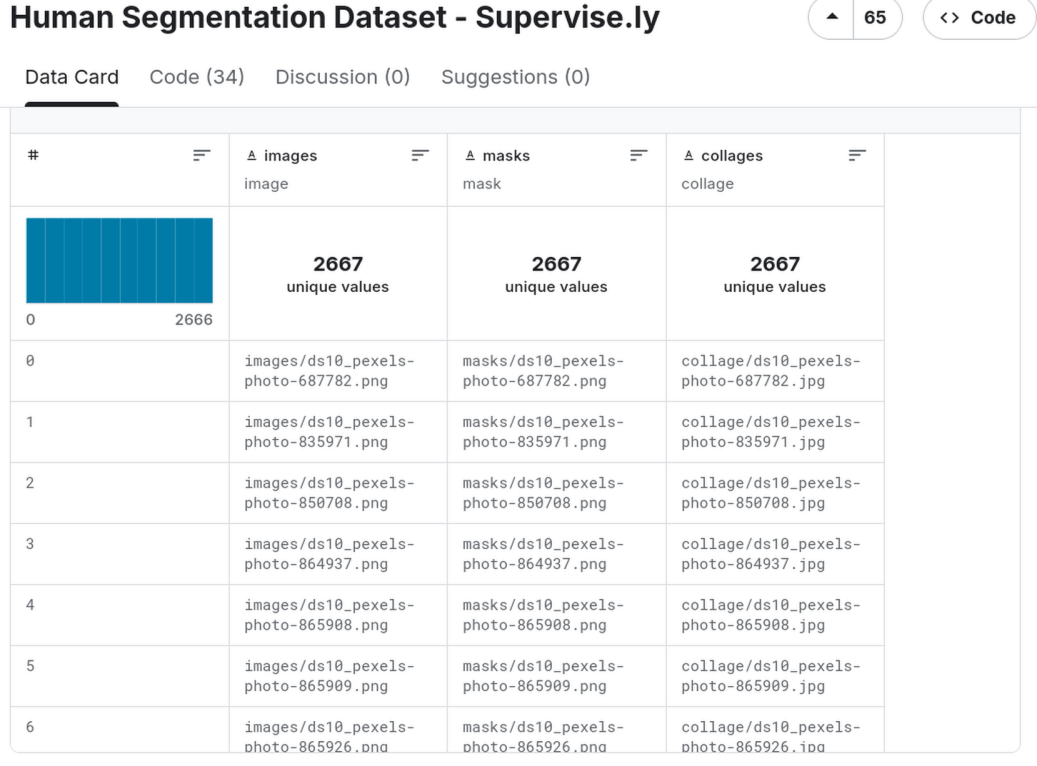

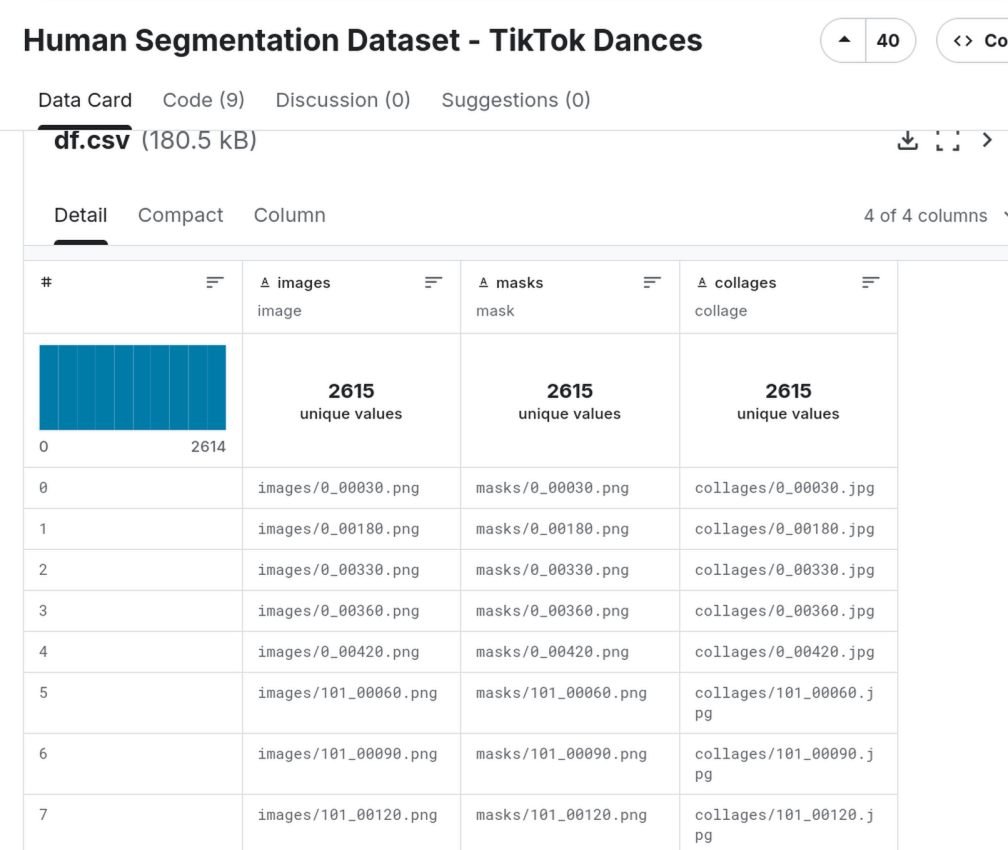

In [2]:
from __future__ import annotations

from pathlib import Path
from zipfile import ZipFile
import gdown


def download_and_extract_many_from_gdrive(
    files: dict[str, str],
    output_root: str,
    delete_zip: bool = True,
) -> dict[str, str]:

    root = Path(output_root)
    root.mkdir(parents=True, exist_ok=True)

    extracted_dirs: dict[str, str] = {}

    for folder_name, file_id in files.items():
        out_path = root / folder_name
        out_path.mkdir(parents=True, exist_ok=True)

        zip_path = out_path / f"{folder_name}.zip"
        url = f"https://drive.google.com/uc?id={file_id}"

        # Download
        gdown.download(url, str(zip_path), quiet=False)

        # Extract
        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(out_path)

        # Cleanup
        if delete_zip and zip_path.exists():
            zip_path.unlink()

        extracted_dirs[folder_name] = str(out_path)

    return extracted_dirs

In [3]:
FILES = {
    "person_segmentation": "1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH",
    "supervisely_person": "15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv",
    "tiktok_dance_segmentation": "1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g",
}

paths = download_and_extract_many_from_gdrive(FILES, "../data/01_raw", delete_zip=True)
print(paths)

Downloading...
From (original): https://drive.google.com/uc?id=1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH
From (redirected): https://drive.google.com/uc?id=1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH&confirm=t&uuid=2d172b95-56f2-468b-bc83-3f63c251f551
To: /home/sam/Documents/AIAD/kedro/background-removal/data/01_raw/person_segmentation/person_segmentation.zip
100%|██████████| 483M/483M [00:04<00:00, 110MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv
From (redirected): https://drive.google.com/uc?id=15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv&confirm=t&uuid=cef6561d-5f50-486c-91a4-01c7fc5c94d7
To: /home/sam/Documents/AIAD/kedro/background-removal/data/01_raw/supervisely_person/supervisely_person.zip
100%|██████████| 4.62G/4.62G [00:40<00:00, 114MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g
From (redirected): https://drive.google.com/uc?id=1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g&confirm=t&uuid=1a0a898c-dc1a-46

{'person_segmentation': '../data/01_raw/person_segmentation', 'supervisely_person': '../data/01_raw/supervisely_person', 'tiktok_dance_segmentation': '../data/01_raw/tiktok_dance_segmentation'}


# Import librarys

In [2]:
import os
import random
import numpy as np 
import pandas as pd 
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, models, optimizers, losses, metrics



2026-02-21 07:42:26.120079: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-21 07:42:26.120111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-21 07:42:26.121172: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-21 07:42:26.126783: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 07:42:26.755995: W tensorflow/compiler/tf2

In [5]:
df =  pd.read_csv('../data/01_raw/supervisely_person/df.csv')

In [6]:
df.head()

,Unnamed: 0,images,masks,collages
0,0,images/ds10_pexels-photo-687782.png,masks/ds10_pexels-photo-687782.png,collage/ds10_pexels-photo-687782.jpg
1,1,images/ds10_pexels-photo-835971.png,masks/ds10_pexels-photo-835971.png,collage/ds10_pexels-photo-835971.jpg
2,2,images/ds10_pexels-photo-850708.png,masks/ds10_pexels-photo-850708.png,collage/ds10_pexels-photo-850708.jpg
3,3,images/ds10_pexels-photo-864937.png,masks/ds10_pexels-photo-864937.png,collage/ds10_pexels-photo-864937.jpg
4,4,images/ds10_pexels-photo-865908.png,masks/ds10_pexels-photo-865908.png,collage/ds10_pexels-photo-865908.jpg


In [7]:
images_path =  "../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/"
masks_path  = "../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/"

images_path2="../data/01_raw/person_segmentation/people_segmentation/images/"
masks_path2="../data/01_raw/person_segmentation/people_segmentation/masks/"

In [8]:
images_path2_list = sorted(os.listdir(images_path2))
masks_path2_list = sorted(os.listdir(masks_path2))

In [9]:
df2 = df[["images", "masks"]]

In [10]:
df2["images"] = df2['images'].apply(lambda x: images_path + x)
df2["masks"] = df2['masks'].apply(lambda x: masks_path + x)

/tmp/ipykernel_211001/2414658170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["images"] = df2['images'].apply(lambda x: images_path + x)
/tmp/ipykernel_211001/2414658170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["masks"] = df2['masks'].apply(lambda x: masks_path + x)


In [11]:
df2.head()

,images,masks
0,../data/01_raw/supervisely_person/supervisely_...,../data/01_raw/supervisely_person/supervisely_...
1,../data/01_raw/supervisely_person/supervisely_...,../data/01_raw/supervisely_person/supervisely_...
2,../data/01_raw/supervisely_person/supervisely_...,../data/01_raw/supervisely_person/supervisely_...
3,../data/01_raw/supervisely_person/supervisely_...,../data/01_raw/supervisely_person/supervisely_...
4,../data/01_raw/supervisely_person/supervisely_...,../data/01_raw/supervisely_person/supervisely_...


In [12]:
df3 =pd.DataFrame({
    "images": [images_path2 + elt for elt in images_path2_list],
    "masks":[masks_path2+ elt for elt in masks_path2_list],
    "coef":255
})

In [13]:
final_df =  pd.concat([df2, df3])

In [ ]:
def load_and_preprocess_image(image_path, is_mask=False, coef=255):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=1 if is_mask else 3) 
    if is_mask:
      image = image*tf.cast(coef, tf.uint8)
    if is_mask:
        image = tf.image.resize(image, [256*2, 256*2], method=tf.image.ResizeMethod.BILINEAR)
        image=tf.where(image < 125, 0, 255)
        image = image//255
        image = tf.cast(image, tf.uint8)
    else :
        image = tf.image.resize(image, [256*2, 256*2], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        image = image/255
        image = tf.cast(image, tf.float32)
    return image

def process_path(image_path, mask_path, coef=255):
        image = load_and_preprocess_image(image_path, False,coef)
        mask = load_and_preprocess_image(mask_path, True, coef)
        return image, mask

def load_dataset(df, batch_size=32):
    image_paths  = df['images']
    mask_path  = df['masks']
    coef = df['coef']
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_path, coef))
    dataset = dataset.map(lambda image, mask, coef: process_path(image, mask, coef))
    augmented_dataset = dataset.map(apply_augmentation)
    final_dataset = dataset.concatenate(augmented_dataset)
    final_dataset = final_dataset.batch(batch_size).shuffle(1000).prefetch(tf.data.AUTOTUNE)
    return final_dataset

In [16]:
X_train, X_test  =  train_test_split(final_df,test_size=0.1)

In [17]:
X_test.shape

(835, 3)

In [18]:
train_dataset =  load_dataset(X_train, 40)
validation_dataset  = load_dataset(X_test, 40)

2026-02-21 07:41:18.438673: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-21 07:41:18.476109: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Modeling

In [19]:
def unet_resnet50(input_shape=(256, 256, 3),C=64, num_classes=1):
 
    inputs = layers.Input(shape=input_shape)


    base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)


    c1 = base_model.get_layer("conv1_relu").output        
    c2 = base_model.get_layer("conv2_block3_out").output 
    c3 = base_model.get_layer("conv3_block4_out").output  
    c4 = base_model.get_layer("conv4_block6_out").output  
    bottleneck = base_model.get_layer("conv5_block3_out").output  


    u6 = layers.Conv2DTranspose(8*C, (2,2), strides=2, padding='same')(bottleneck)
    u6 = layers.Concatenate()([u6, c4])
    c6 = layers.Conv2D(8*C, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(8*C, (3,3), activation='relu', padding='same')(c6)
    c6 = layers.BatchNormalization()(c6)

  
    u7 = layers.Conv2DTranspose(4*C, (2,2), strides=2, padding='same')(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = layers.Conv2D(4*C, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(4*C, (3,3), activation='relu', padding='same')(c7)
    c7 = layers.BatchNormalization()(c7)

  
    u8 = layers.Conv2DTranspose(2*C, (2,2), strides=2, padding='same')(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = layers.Conv2D(2*C, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Conv2D(2*C, (3,3), activation='relu', padding='same')(c8)
    c8 = layers.BatchNormalization()(c8)

  
    u9 = layers.Conv2DTranspose(C, (2,2), strides=2, padding='same')(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = layers.Conv2D(C, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Conv2D(C, (3,3), activation='relu', padding='same')(c9)
    c9 = layers.BatchNormalization()(c9)

 
    u10 = layers.Conv2DTranspose(C, (2,2), strides=2, padding='same')(c9)
    c10 = layers.Conv2D(C, (3,3), activation='relu', padding='same')(u10)
    c10 = layers.BatchNormalization()(c10)

    if num_classes == 1:
        outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c10)
    else:
        outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c10)

  
    model = models.Model(inputs, outputs)
    return model


In [20]:
model = unet_resnet50(input_shape=(512,512,3), C=32)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss="binary_crossentropy",
                  metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 518, 518, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 256, 256, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 256, 256, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

# *Training*

In [1]:
import sys, site, tensorflow as tf
print("python:", sys.executable)
print("site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")
print("TF:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-02-21 12:32:58.999432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


python: /home/sam/anaconda3/envs/aiad-tf-gpu/bin/python
site-packages: ['/home/sam/anaconda3/envs/aiad-tf-gpu/lib/python3.10/site-packages']
TF: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]="0"
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
print("Using GPU?" , bool(tf.config.list_physical_devices("GPU")))

Using GPU? True


In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
model.fit(train_dataset, validation_data=validation_dataset, epochs=5)

Epoch 1/5


2026-02-21 07:41:40.548950: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:5: Filling up shuffle buffer (this may take a while): 77 of 1000


In [ ]:

sample_paths = final_df.sample(10)['images'].tolist()

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(10, 60))

for i, path in enumerate(sample_paths):
    predict_image = load_and_preprocess_image(path)
    predict = model.predict(np.array([predict_image]))
    predict = np.reshape(predict, (512, 512))
    predict_change = predict > 0.5

    axes[i, 0].imshow(predict_image)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(predict_change * 255, cmap="gray")
    axes[i, 1].set_title('Mask')
    axes[i, 1].axis('off')


    img = np.array(Image.open(path).resize((512, 512)))
    no_bg = img * np.stack((predict_change,) * 3, axis=-1)
    axes[i, 2].imshow(no_bg.astype(np.uint8))
    axes[i, 2].set_title('Without background')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
model.save("my_model.keras")